In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# 1. 데이터 준비
num_classes = 10
input_shape = (28, 28, 1)

**1. Training Set X,Y 설정**

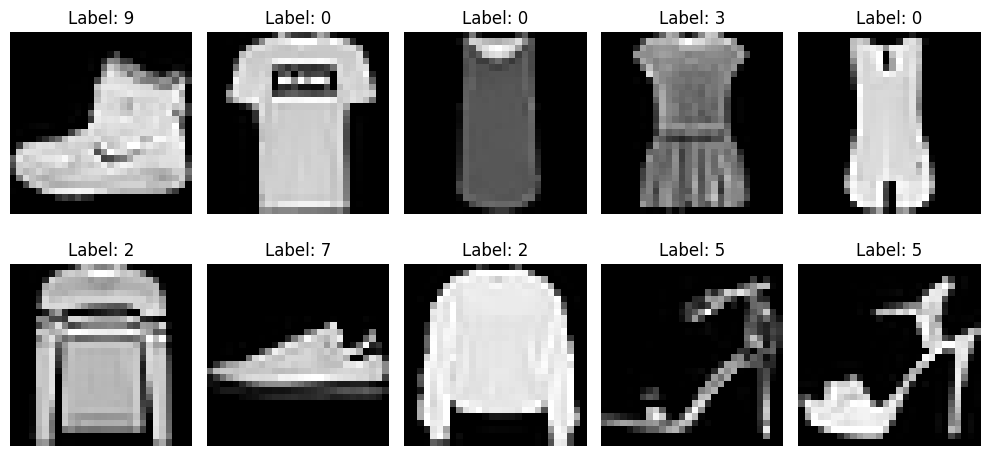

In [4]:
# MNIST 데이터셋 로드
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
np.set_printoptions(linewidth=200, threshold=np.inf)
pd.set_option("display.max_columns", 50)   # 기본은 20, 늘려주면 생략 안 됨
pd.set_option("display.width", 300)   
# 처음 10개의 이미지를 화면에 출력하여 확인
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [5]:
    # 이미지 픽셀 값을 0 ~ 1 사이로 정규화
    x_train = x_train.astype("float32") / 255
    x_test = x_test.astype("float32") / 255


In [6]:
    # 차원 추가 (샘플 수, 28, 28) -> (샘플 수, 28, 28, 1) CNN는 높이x너비x채널수로 받음, Gray라 채널이 1개
    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)

    print("x_train shape:", x_train.shape)
    print(x_train.shape[0], "train samples")
    print(x_test.shape[0], "test samples")

    # 레이블을 원-핫 인코딩(One-hot encoding)으로 변환
    y_train = keras.utils.to_categorical(y_train, num_classes)
    y_test = keras.utils.to_categorical(y_test, num_classes)

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


**모델 구성**

In [7]:
    # 2. CNN 모델 구성
    model = keras.Sequential(
        [
            keras.Input(shape=input_shape),
            #3x3 크기의 필터 32개를 사용해 이미지의 특징을 추출, 미지의 저수준 특징(엣지 등)
            layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
            #이미지의 가로세로 크기를 절반으로 줄임(이미지를 2x2로 나누구 그 중에서 제일 큰 값 하나 고름)
            layers.MaxPooling2D(pool_size=(2, 2)),
            #더 많은 필터(64개)를 사용해 앞서 추출된 특징들을 조합한 더 복잡한 패턴을 학습합니다.
            layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            #2차원(행, 열) 형태의 특징 맵을 1차원 벡터로 쭉 핌.
            layers.Flatten(),
            #학습 시 무작위로 뉴런의 50%를 끔. 특정 뉴런에만 의존하는 것을 방지하여 **과적합(Overfitting)**을 막는 아주 효과적인 장치
            layers.Dropout(0.5),
            #MNIST의 경우 0~9까지 10개의 클래스가 있는데 각 숫자에 해당할 확률을 합계가 1(100%)이 되도록 출력
            layers.Dense(num_classes, activation="softmax"),
        ]
    )

    model.summary()

    # 3. 모델 학습 설정 및 학습 진행
    # 128개씩 끊어서 학습하고 검증 한다. 전체 데이터를 5번 반복한다.
    batch_size = 128
    epochs = 5

    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │          16,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

**모델 학습**

In [8]:
    print("\n모델 학습을 시작합니다...")
    model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)


모델 학습을 시작합니다...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.7499 - loss: 0.6916 - val_accuracy: 0.8418 - val_loss: 0.4401
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8367 - loss: 0.4499 - val_accuracy: 0.8618 - val_loss: 0.3868
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.8557 - loss: 0.4037 - val_accuracy: 0.8763 - val_loss: 0.3481
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8649 - loss: 0.3745 - val_accuracy: 0.8815 - val_loss: 0.3328
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8725 - loss: 0.3547 - val_accuracy: 0.8877 - val_loss: 0.3184


In [9]:
    # 4. 모델 평가
    score = model.evaluate(x_test, y_test, verbose=0)
    print("\n--- 학습 결과 ---")
    print("Test loss:", score[0])
    print("Test accuracy:", score[1])


--- 학습 결과 ---
Test loss: 0.3400309681892395
Test accuracy: 0.8794999718666077


In [10]:
sample=x_test[0]
sample=np.expand_dims(sample,axis=0)
model.predict(sample)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


array([[1.2896776e-07, 4.6729194e-09, 4.1477875e-08, 6.8383628e-08, 2.1501259e-07, 3.6498778e-03, 4.8941843e-07, 1.6240679e-02, 6.5930473e-04, 9.7944915e-01]], dtype=float32)